Number of rows: 2000
Number of columns: 17

Input Feature Types:
 customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Missing Values:
 customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_in

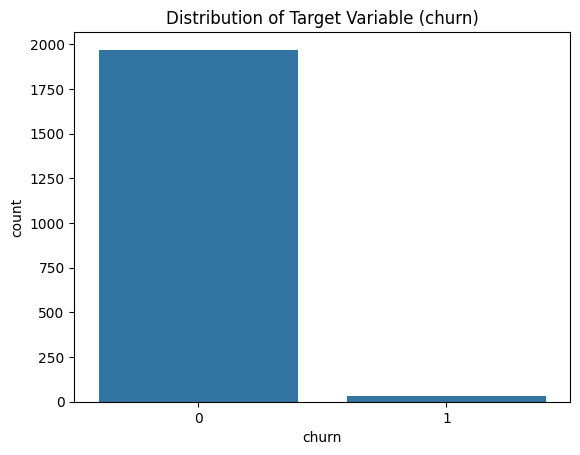

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
path = r'C:\Users\dhanw\Downloads\customer_churn_nn.csv'
df = pd.read_csv(path)

# Basic Exploration
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\nInput Feature Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistical Summary:\n", df.describe())

# Target variable distribution
sns.countplot(x='churn', data=df)
plt.title('Distribution of Target Variable (churn)')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Handle Categorical Columns (Encoding)
le = LabelEncoder()
# Select all object/string columns for encoding
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = le.fit_transform(df[col])

# 2. Splitting Features (X) and Target (y)
X = df.drop('churn', axis=1)
y = df['churn']

# 3. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scaling Numerical Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Iteration 1, loss = 1.05743813
Iteration 2, loss = 0.98107754
Iteration 3, loss = 0.90906695
Iteration 4, loss = 0.84178726
Iteration 5, loss = 0.77878576
Iteration 6, loss = 0.72191850
Iteration 7, loss = 0.66761301
Iteration 8, loss = 0.61897141
Iteration 9, loss = 0.57388040
Iteration 10, loss = 0.53188804
Iteration 11, loss = 0.49364575
Iteration 12, loss = 0.45917802
Iteration 13, loss = 0.42725211
Iteration 14, loss = 0.39806105
Iteration 15, loss = 0.37149801
Iteration 16, loss = 0.34696774
Iteration 17, loss = 0.32508648
Iteration 18, loss = 0.30478184
Iteration 19, loss = 0.28644238
Iteration 20, loss = 0.26983922
Iteration 21, loss = 0.25466351
Iteration 22, loss = 0.24069193
Iteration 23, loss = 0.22806211
Iteration 24, loss = 0.21652318
Iteration 25, loss = 0.20596901
Iteration 26, loss = 0.19631449
Iteration 27, loss = 0.18742653
Iteration 28, loss = 0.17933693
Iteration 29, loss = 0.17205513
Iteration 30, loss = 0.16528571
Iteration 31, loss = 0.15899464
Iteration 32, los

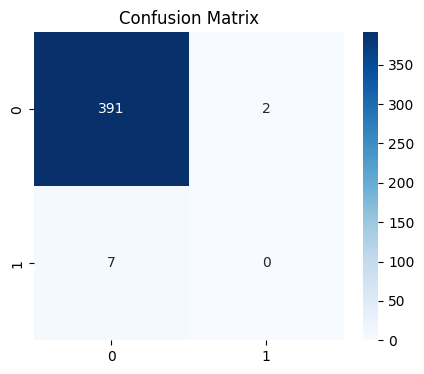

In [5]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Building the Model
# 1 hidden layer with 16 neurons, ReLU activation, Adam optimizer
model = MLPClassifier(hidden_layer_sizes=(16,), activation='relu', solver='adam', 
                    max_iter=500, random_state=42, verbose=True)

# Training
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print(f"\nTesting Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [6]:
# Experiment 1: Different Hidden Layers (Deeper Model)
exp1 = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42).fit(X_train, y_train)

# Experiment 2: Higher Learning Rate
exp2 = MLPClassifier(hidden_layer_sizes=(16,), learning_rate_init=0.1, max_iter=500, random_state=42).fit(X_train, y_train)

# Experiment 3: Different Activation (Tanh)
exp3 = MLPClassifier(hidden_layer_sizes=(16,), activation='tanh', max_iter=500, random_state=42).fit(X_train, y_train)

# Comparison Table
data = {
    "Configuration": ["Base (16, ReLU, 0.001)", "Deeper (32, 16)", "High LR (0.1)", "Tanh Activation"],
    "Accuracy (%)": [model.score(X_test, y_test)*100, exp1.score(X_test, y_test)*100, 
                     exp2.score(X_test, y_test)*100, exp3.score(X_test, y_test)*100]
}
comparison_df = pd.DataFrame(data)
print(comparison_df)
# Save this table for Task 5 requirements
comparison_df.to_csv('model_comparison_table.csv', index=False)

            Configuration  Accuracy (%)
0  Base (16, ReLU, 0.001)         97.75
1         Deeper (32, 16)         98.75
2           High LR (0.1)         98.00
3         Tanh Activation         98.25
